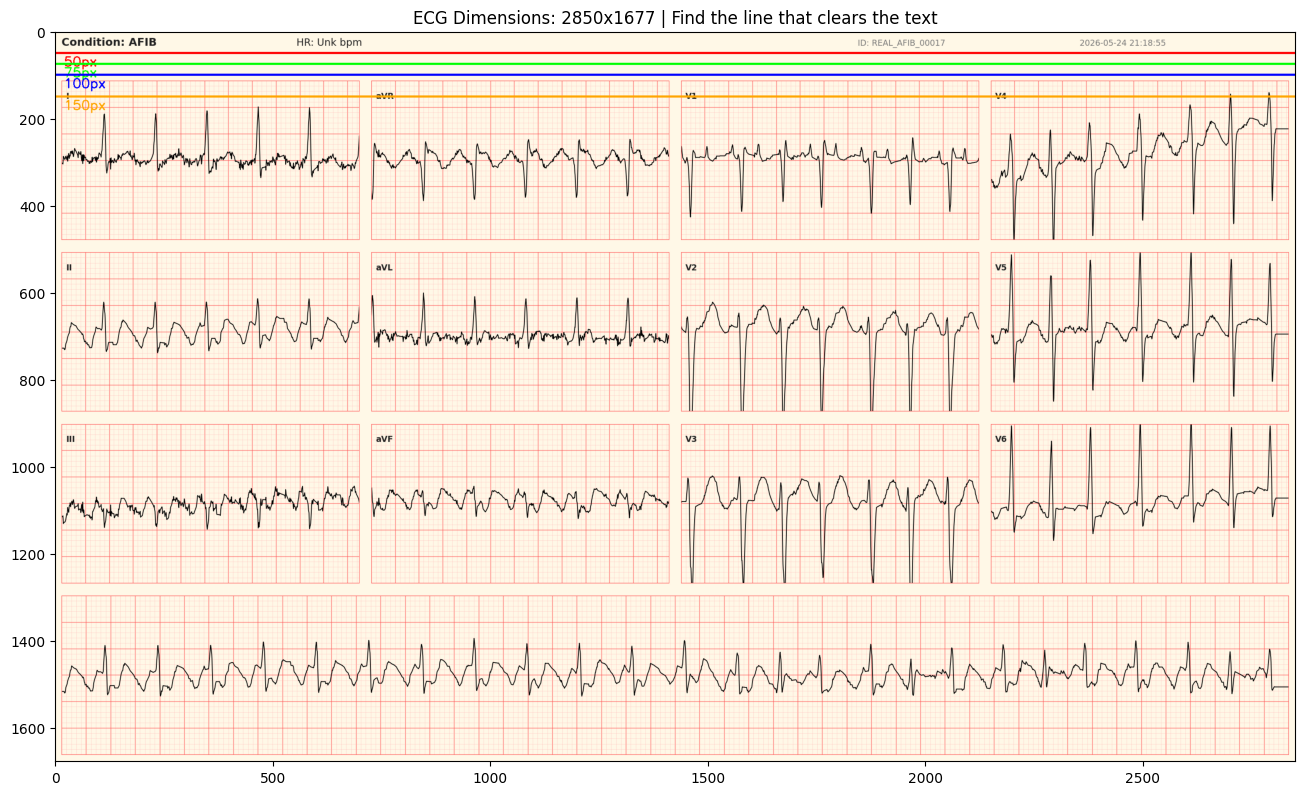

Total image height is 1677 pixels.


In [4]:
import cv2
import matplotlib.pyplot as plt

# Updated the extension from .jpg to .png
test_image_path = "C:/Users/admin/OneDrive/Desktop/ECG-Generative-Augmentation/data/raw/real/AFIB/REAL_AFIB_00017.png"

img = cv2.imread(test_image_path)

if img is None:
    print("Could not find the image. Please check the file path!")
else:
    # Convert from BGR to RGB for correct colors in matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, _ = img.shape
    
    # Draw guide lines across the image to find the text boundary
    test_heights = [50, 75, 100, 150]
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 165, 0)] # Red, Green, Blue, Orange
    
    for h, color in zip(test_heights, colors):
        cv2.line(img_rgb, (0, h), (width, h), color, 3)
        cv2.putText(img_rgb, f"{h}px", (20, h + 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # Display the image
    plt.figure(figsize=(16, 10))
    plt.imshow(img_rgb)
    plt.title(f"ECG Dimensions: {width}x{height} | Find the line that clears the text")
    plt.axis("on") 
    plt.show()
    
    print(f"Total image height is {height} pixels.")

In [5]:
import cv2
import os
from tqdm import tqdm

# Set the absolute paths to avoid any VS Code directory confusion
RAW_REAL_DIR = "C:/Users/admin/OneDrive/Desktop/ECG-Generative-Augmentation/data/raw/real"
CLEANED_REAL_DIR = "C:/Users/admin/OneDrive/Desktop/ECG-Generative-Augmentation/data/cleaned/real"

# The perfectly measured height to block the text but save the grid!
HEADER_HEIGHT = 85 

print("Starting batch masking of real ECG dataset (.png files)...")

# Loop through all directories and files recursively
for root, dirs, files in os.walk(RAW_REAL_DIR):
    for filename in tqdm(files):
        # We now specifically look for .png files!
        if filename.lower().endswith('.png'):
            
            raw_img_path = os.path.join(root, filename)
            rel_path = os.path.relpath(root, RAW_REAL_DIR)
            clean_target_dir = os.path.join(CLEANED_REAL_DIR, rel_path)
            
            os.makedirs(clean_target_dir, exist_ok=True)
            
            img = cv2.imread(raw_img_path)
            if img is None:
                continue
                
            # Apply the solid masking rectangle
            height, width, _ = img.shape
            sampled_bg_color = [int(c) for c in img[10, width - 10]]
            cv2.rectangle(img, (0, 0), (width, HEADER_HEIGHT), sampled_bg_color, -1)
            
            # Save the cleaned image
            clean_img_path = os.path.join(clean_target_dir, filename)
            cv2.imwrite(clean_img_path, img)

print("Success! All text labels have been permanently removed.")

Starting batch masking of real ECG dataset (.png files)...


100%|██████████| 319/319 [00:41<00:00,  7.75it/s]

Success! All text labels have been permanently removed.
